# Voorbeeld waterstandsverloop

In dit voorbeeld gebruiken we een eenvoudige waterstandsverloop generator om de onzekerheid in waterstandsverlopen te verkennen. 

In het benedenrivierengebied wordt een hoogwater veroorzaakt door een combinatie van een getijdebeweging, stormopzet en afvoergolf. Gegeven een bereikte topwaterstand kan de bijdrage van de getijde, afvoer en stormopzet verschillen. In dit voorbeeld maken we gebruik van de de uitvoerlocatie `sss`.

De topwaterstand $h_{top}$ bij een overschrijdingsfrequentie $T = 10.000$ jaar is xx m+NAP.
De waterstand onder dagelijkse condities is $h_{gem}$ is xx m+NAP.

Hydra-NL geeft als resultaat een verdeling van de afvoer gegeven de topwaterstand. We zetten deze afvoer om naar een verdeling van de amplitude van de afvoer.

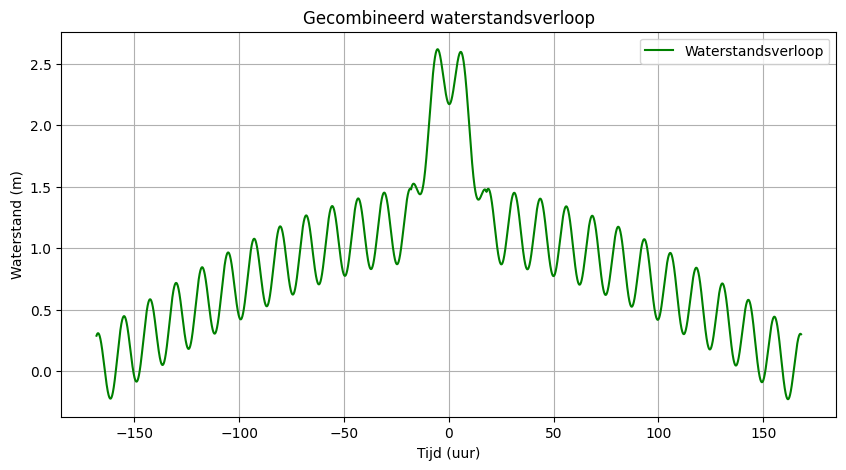

In [1]:
from wsbd.waterstandsverloop import ComponentWaterstandsVerloop, GetijdeVerloop, WaterstandsVerloop

topwaterstand = 3.77
gemiddelde_waterstand = 1.0
amplitude_getijde = 0.3
amplitude_afvoergolf = 1.2
amplitude_stormopzet = topwaterstand - gemiddelde_waterstand - amplitude_getijde - amplitude_afvoergolf

getijde = GetijdeVerloop(periode=(12*3600+25*60), amplitude=amplitude_getijde, faseverschuiving=-6*3600, dt=1.0)
afvoergolf = ComponentWaterstandsVerloop(component='afvoergolf', stormduur=14*24*3600, amplitude=amplitude_afvoergolf, dt=1.0)
stormopzet = ComponentWaterstandsVerloop(component='stormopzet', stormduur=36*3600, amplitude=amplitude_stormopzet, dt=1.0)

waterstandsverloop = WaterstandsVerloop(afvoergolf=afvoergolf, stormopzet=stormopzet, getijde=getijde, dt=1.0)

waterstandsverloop.plot(normalised=False)